<a href="https://colab.research.google.com/github/Pranamchand/Costomer-churn-EDA/blob/main/Anime_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Anime Dataset EDA Project

### TODO
- Import Data
     - Load dataset
     - Check shape, columns and datatype
- Understand the meaning behind each column
- Questions & Hypothesis
- Data processing and cleaning
     - Missing values
     - Duplicates
     - Wrong datatypes
- EDA and Visualisation
- Key Findings / Insights
- Summary and Conclusion
- Posting on LinkedIn

## Data set used
- Anime_Data

# Import Data

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('anime_dataset.csv')

In [ ]:
df.shape

(30075, 29)

In [ ]:
df.head()

,mal_id,title,title_english,title_japanese,type,source,episodes,status,airing,aired_from,...,season,year,studios,producers,licensors,genres,themes,demographics,synopsis,image_url
0,1,Cowboy Bebop,Cowboy Bebop,カウボーイビバップ,TV,Original,26.0,Finished Airing,False,1998-04-03,...,spring,1998.0,Sunrise,Bandai Visual|Victor Entertainment|Audio Plann...,Funimation,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,"Crime is timeless. By the year 2071, humanity ...",https://myanimelist.net/images/anime/4/19644.jpg
1,5,Cowboy Bebop: Tengoku no Tobira,Cowboy Bebop: The Movie,カウボーイビバップ 天国の扉,Movie,Original,1.0,Finished Airing,False,2001-09-01,...,NaN,NaN,Bones,Sunrise|Bandai Visual,Sony Pictures Entertainment|Funimation,Action|Sci-Fi,Adult Cast|Space,NaN,"Another day, another bounty—such is the life o...",https://myanimelist.net/images/anime/1439/9348...
2,6,Trigun,Trigun,トライガン,TV,Manga,26.0,Finished Airing,False,1998-04-01,...,spring,1998.0,Madhouse,Victor Entertainment|Arts Pro,Funimation,Action|Adventure|Sci-Fi,Adult Cast,Shounen,"Vash the Stampede is the man with a $$60,000,0...",https://myanimelist.net/images/anime/1130/1200...
3,7,Witch Hunter Robin,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),TV,Original,26.0,Finished Airing,False,2002-07-03,...,summer,2002.0,Sunrise,Bandai Visual|Dentsu|Victor Entertainment,Funimation|Bandai Entertainment,Action|Drama|Mystery|Supernatural,Detective,NaN,"Though hidden away from the general public, Wi...",https://myanimelist.net/images/anime/10/19969.jpg
4,8,Bouken Ou Beet,Beet the Vandel Buster,冒険王ビィト,TV,Manga,52.0,Finished Airing,False,2004-09-30,...,fall,2004.0,Toei Animation,TV Tokyo|Dentsu,Illumitoon Entertainment,Action|Adventure|Fantasy,NaN,Shounen,It is the dark century and the people are suff...,https://myanimelist.net/images/anime/7/21569.jpg


### Columns to drop
 - title_japanese
 - synopsis
 - producers
 - licensors
 - themes
 - image_url

In [ ]:
df = df.drop(['title_japanese', 'synopsis', 'producers', 'licensors', 'themes', 'image_url'], axis = 1)

In [ ]:
df.columns

Index(['mal_id', 'title', 'title_english', 'type', 'source', 'episodes',
       'status', 'airing', 'aired_from', 'aired_to', 'duration', 'rating',
       'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites',
       'season', 'year', 'studios', 'genres', 'demographics'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30075 entries, 0 to 30074
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   mal_id         30075 non-null  int64  
 1   title          30075 non-null  str    
 2   title_english  13306 non-null  str    
 3   type           30003 non-null  str    
 4   source         30075 non-null  str    
 5   episodes       29236 non-null  float64
 6   status         30075 non-null  str    
 7   airing         30075 non-null  bool   
 8   aired_from     29166 non-null  str    
 9   aired_to       11594 non-null  str    
 10  duration       30075 non-null  str    
 11  rating         29473 non-null  str    
 12  score          19892 non-null  float64
 13  scored_by      19892 non-null  float64
 14  rank           22584 non-null  float64
 15  popularity     30075 non-null  int64  
 16  members        30075 non-null  int64  
 17  favorites      30075 non-null  int64  
 18  season         65

### Understanding some Ambigous columns
- score - rating of the anime out of ten, some Anime don't have score because no one give them one
- Year has maxmum NA value so it can't be used in particular
- Most of the TV showes are anime with more then one episodes.
- scored_by - No of users who rated the Anime
- rank - Rank based on Score
- members - Total users who added anime to their list
- popularity - ranking based on member count
- favorites - users who add the anime to fevorite

# Data processing and cleaning

In [ ]:
df.duplicated().sum()

np.int64(139)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(29936, 23)

In [ ]:
pd.set_option('display.max_columns', None)

In [ ]:
df['aired_from'] = pd.to_datetime(df['aired_from'], errors = 'coerce')
df['aired_to'] = pd.to_datetime(df['aired_to'], errors = 'coerce')

In [ ]:
(df['aired_from'].dt.year  == df['year']).value_counts()

False    23536
True      6400
Name: count, dtype: int64

From here we conclude that we don't actually need the year column.

In [ ]:
df = df.drop('year', axis = 1)

In [ ]:
df.isna().sum().sort_values(ascending = False)

season           23451
demographics     18848
aired_to         18351
title_english    16715
studios          11888
score            10068
scored_by        10068
rank              7387
genres            6377
aired_from         871
episodes           746
rating             554
type                64
mal_id               0
source               0
title                0
airing               0
status               0
duration             0
favorites            0
popularity           0
members              0
dtype: int64

# EDA and Visualisation

In [ ]:
green_palate = ['#0B3D2E',
               '#14532D',
               '#166534',
               '#15803D',
               '#16A34A',
               '#22C55E',
               '#4ADE80',
               '#86EFAC',
               '#DCFCE7']

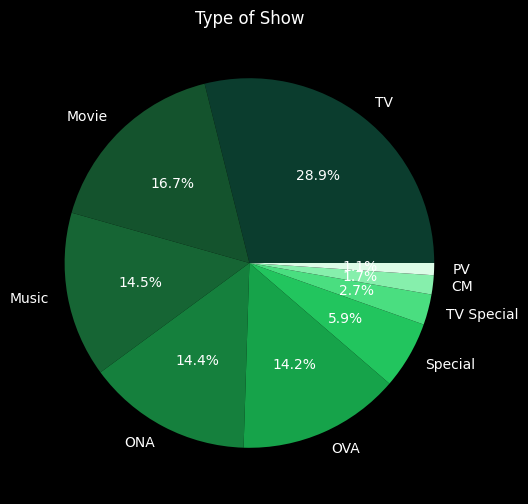

In [ ]:
plt.style.use('dark_background')
df["type"].value_counts(dropna = True).plot(
    kind='pie',
    figsize=(6,6),
    autopct = '%1.1f%%',
    colors = green_palate
)
plt.title("Type of Show")
plt.show()

In [ ]:
type_tv = df[df['type'] == 'TV']
type_tv[type_tv['episodes'] < 2]

,mal_id,title,title_english,type,source,episodes,status,airing,aired_from,aired_to,duration,rating,score,scored_by,rank,popularity,members,favorites,season,studios,genres,demographics
20779,48322,Jouiseon-in,Warriors in Black,TV,Original,1.0,Finished Airing,False,2008-01-01,NaT,13 min,G - All Ages,NaN,NaN,17627.0,25543,136,0,NaN,NaN,Action|Fantasy,Kids


In [ ]:
source_count = df['source'].value_counts()

In [ ]:
(source_count / sum(source_count) * 100)

source
Original        43.015099
Manga           18.903661
Unknown          9.146179
Game             5.130946
Other            4.599813
Light novel      4.188936
Visual novel     3.898316
Web manga        2.448557
Novel            2.388429
Web novel        1.356227
4-koma manga     1.145778
Picture book     0.968733
Music            0.915286
Mixed media      0.825094
Book             0.754944
Card game        0.267237
Radio            0.046766
Name: count, dtype: float64

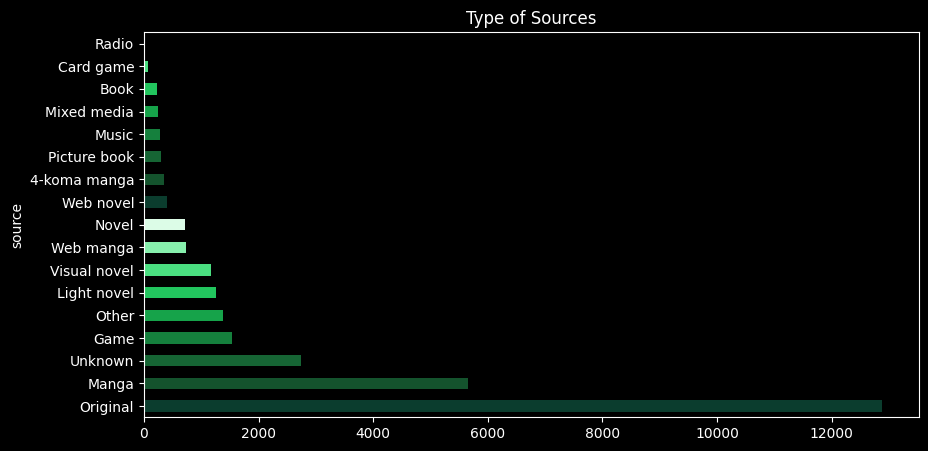

In [ ]:
plt.style.use('dark_background')
df['source'].value_counts().sort_values(ascending = False).plot(kind='barh' , figsize = (10, 5), facecolor=green_palate)
plt.title('Type of Sources')
plt.show()

#### Not like connecting mySQL absolutly needed for some easion it just came to my mind and I did it.

In [ ]:
import mysql.connector
conn= mysql.connector.connect(
    host= 'localhost',
    user= 'root',
    password = 'password',
    database = 'anime'
)

cursor = conn.cursor()

In [ ]:
quary = ''' SELECT source , COUNT(source) FROM anime_data WHERE type = 'TV' GROUP BY source; '''

cursor.execute(quary)

data = cursor.fetchall()

d = pd.DataFrame(data)

(d[1]/sum(d[1])) * 100

0     36.778046
1     23.929269
2      7.911356
3      3.949937
4      1.986451
5      1.952004
6      2.365369
7      4.340338
8      0.998967
9      3.674360
10     9.266276
11     0.057412
12     0.803766
13     1.171202
14     0.574119
15     0.206683
16     0.034447
Name: 1, dtype: float64

In [ ]:
quary = ''' SELECT source , COUNT(source) FROM anime_data GROUP BY source; '''

cursor.execute(quary)

data = cursor.fetchall()

d = pd.DataFrame(data)

(d[1]/sum(d[1])) * 100

0     42.876143
1     18.969244
2      4.246052
3      5.120532
4      3.880299
5      1.140482
6      2.384040
7      4.581879
8      9.107232
9      0.974231
10     2.513716
11     0.914381
12     0.046550
13     0.751455
14     0.834580
15     0.266002
16     1.393184
Name: 1, dtype: float64

In [ ]:
top_episodes = df[df['episodes'] > 1000].sort_values(by = 'episodes', ascending = False)
top_episodes[['title', 'title_english' , 'episodes']]

,title,title_english,episodes
5969,Lan Mao,3000 Whys Of Blue Cat,3000.0
6718,Oyako Club,NaN,1818.0
2266,Doraemon (1979),Doraemon,1787.0
8912,Gudetama,The Lazy Egg,1717.0
19342,Daomei Xiansheng,NaN,1664.0
8873,Kirin Monoshiri Yakata,NaN,1565.0
14604,Pakkororin,Pakkororin,1512.0
4522,Manga Nippon Mukashibanashi (1976),NaN,1471.0
5263,Hokahoka Kazoku,The Affectuous Family,1428.0
11314,Kirin Ashita no Calendar,NaN,1306.0


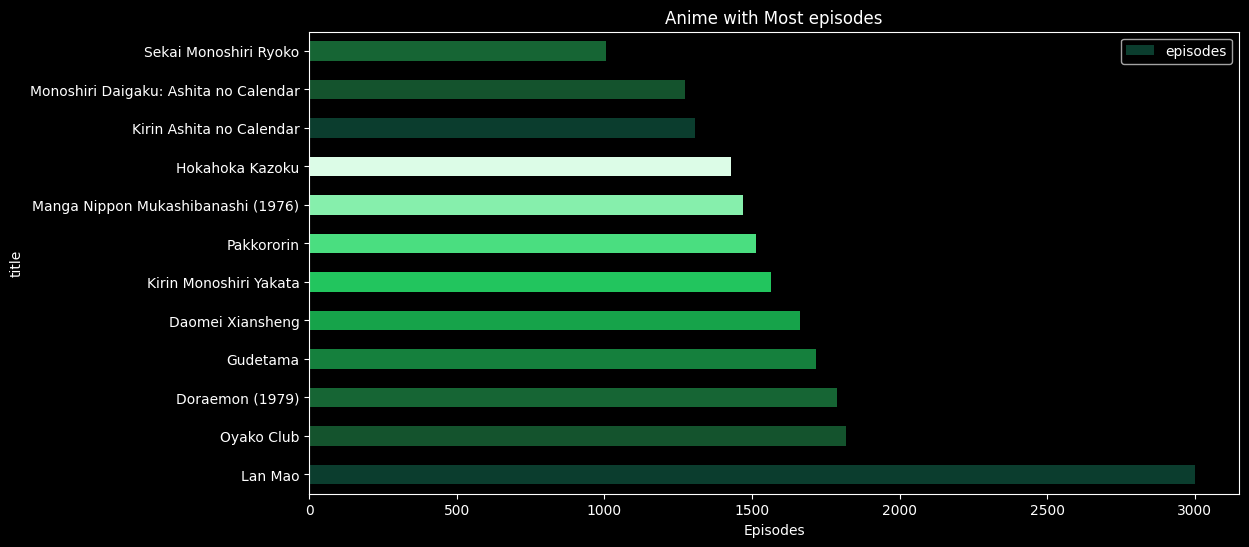

In [ ]:
plt.style.use('dark_background')
top_episodes.plot(kind='barh', x = 'title', y = 'episodes', figsize = (12, 6) ,facecolor = green_palate )
plt.title('Anime with Most episodes')
plt.xlabel('Episodes')
plt.show()

In anime 'One Piece' which originally hsa more then 1000 episodes has multiple NA value in the row along with the episode column, Probably the reasion will be because the Anime was Airings when the Dataset was created .

In [ ]:
df[df['title'] == 'One Piece']

,mal_id,title,title_english,type,source,episodes,status,airing,aired_from,aired_to,duration,rating,score,scored_by,rank,popularity,members,favorites,season,studios,genres,demographics
11,21,One Piece,One Piece,TV,Manga,NaN,Currently Airing,True,1999-10-20,NaT,24 min,PG-13 - Teens 13 or older,8.73,1525171.0,54.0,17,2671030,251194,fall,Toei Animation,Action|Adventure|Fantasy,Shounen


In [ ]:
df[df['title'] == 'Pokemon']

,mal_id,title,title_english,type,source,episodes,status,airing,aired_from,aired_to,duration,rating,score,scored_by,rank,popularity,members,favorites,season,studios,genres,demographics
494,527,Pokemon,Pokémon,TV,Game,276.0,Finished Airing,False,1997-04-01,2002-11-14,24 min per ep,PG - Children,7.42,425267.0,2563.0,354,680775,5836,spring,OLM,Action|Adventure|Comedy|Fantasy,Kids


In [ ]:
corr = df.corr(numeric_only = True)
corr

,mal_id,episodes,airing,score,scored_by,rank,popularity,members,favorites
mal_id,1.000000,-0.018417,0.109430,-0.039726,-0.029631,0.418575,0.519551,-0.101415,-0.060015
episodes,-0.018417,1.000000,0.049032,0.095478,0.050904,0.054609,0.058556,0.028342,0.043805
airing,0.109430,0.049032,1.000000,0.055931,-0.017624,0.001508,-0.014672,-0.012691,0.009202
score,-0.039726,0.095478,0.055931,1.000000,0.336715,-0.974602,-0.647441,0.374302,0.222152
scored_by,-0.029631,0.050904,-0.017624,0.336715,1.000000,-0.319976,-0.359097,0.989594,0.779627
rank,0.418575,0.054609,0.001508,-0.974602,-0.319976,1.000000,0.865981,-0.341987,-0.168041
popularity,0.519551,0.058556,-0.014672,-0.647441,-0.359097,0.865981,1.000000,-0.361431,-0.157751
members,-0.101415,0.028342,-0.012691,0.374302,0.989594,-0.341987,-0.361431,1.000000,0.766499
favorites,-0.060015,0.043805,0.009202,0.222152,0.779627,-0.168041,-0.157751,0.766499,1.000000


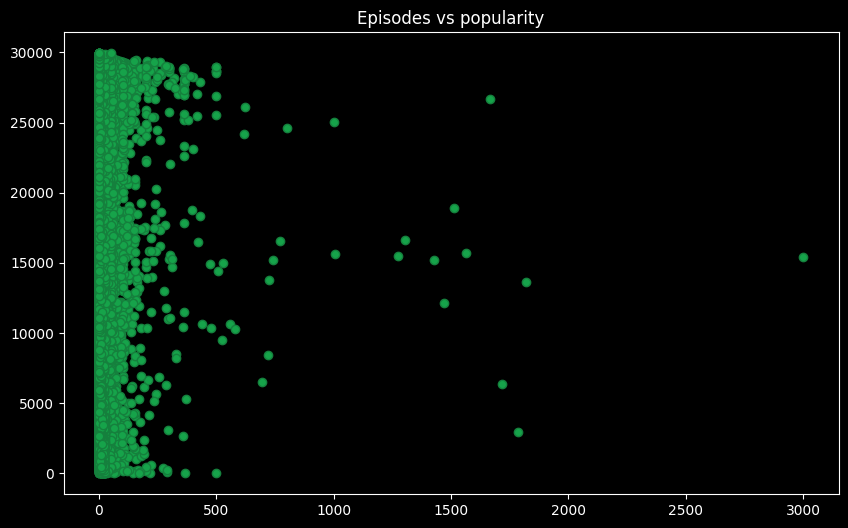

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['episodes'],
    df['popularity'],
    c = '#16A34A',
    edgecolors= '#15803D'
)
plt.title('Episodes vs popularity')
plt.show()

### Using explode function in pandas one can make more rows with the element present in the list in that row .  

In [ ]:
df['genres'] = df['genres'].str.split('|')

In [ ]:
genres_exp = df.explode('genres')

In [ ]:
genres_exp['genres']

0               Action
0        Award Winning
0               Sci-Fi
1               Action
1               Sci-Fi
             ...      
30073           Action
30073        Adventure
30073            Drama
30073          Fantasy
30073          Romance
Name: genres, Length: 49163, dtype: str

In [ ]:
( genres_exp['genres'].value_counts() / genres_exp['genres'].value_counts().sum() ) * 100

genres
Comedy           18.555135
Fantasy          14.392558
Action           11.545833
Adventure        10.650680
Sci-Fi            8.285420
Drama             7.336512
Romance           5.319497
Hentai            3.781611
Supernatural      3.641378
Slice of Life     2.961249
Avant Garde       2.601318
Mystery           2.400318
Sports            1.944561
Ecchi             1.930538
Horror            1.404665
Suspense          1.100827
Award Winning     0.593652
Gourmet           0.577292
Boys Love         0.467443
Girls Love        0.294489
Erotica           0.215024
Name: count, dtype: float64

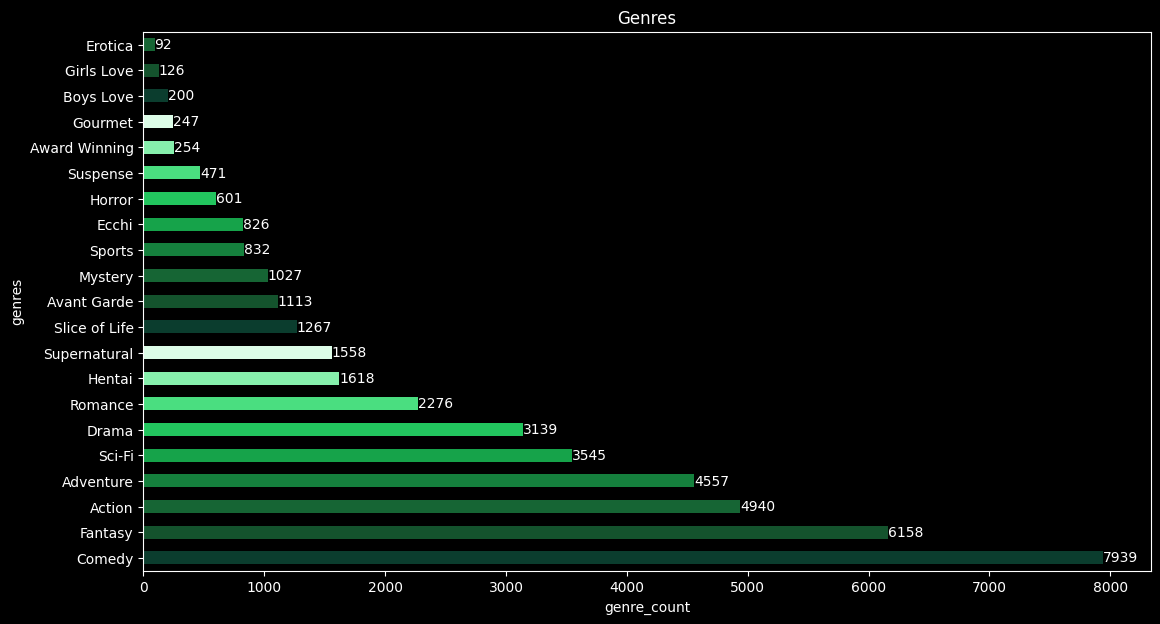

In [ ]:
ax = genres_exp['genres'].value_counts().plot(kind = 'barh', figsize = (13, 7) ,facecolor = green_palate)
plt.title('Genres')
plt.xlabel('genre_count')

ax.bar_label(ax.containers[0])

plt.show()

In [ ]:
popular_genre = df[['title','title_english', 'members', 'popularity', 'genres', 'score', 'rank', 'studios']].sort_values(by = 'popularity' , ascending = True).head(20)

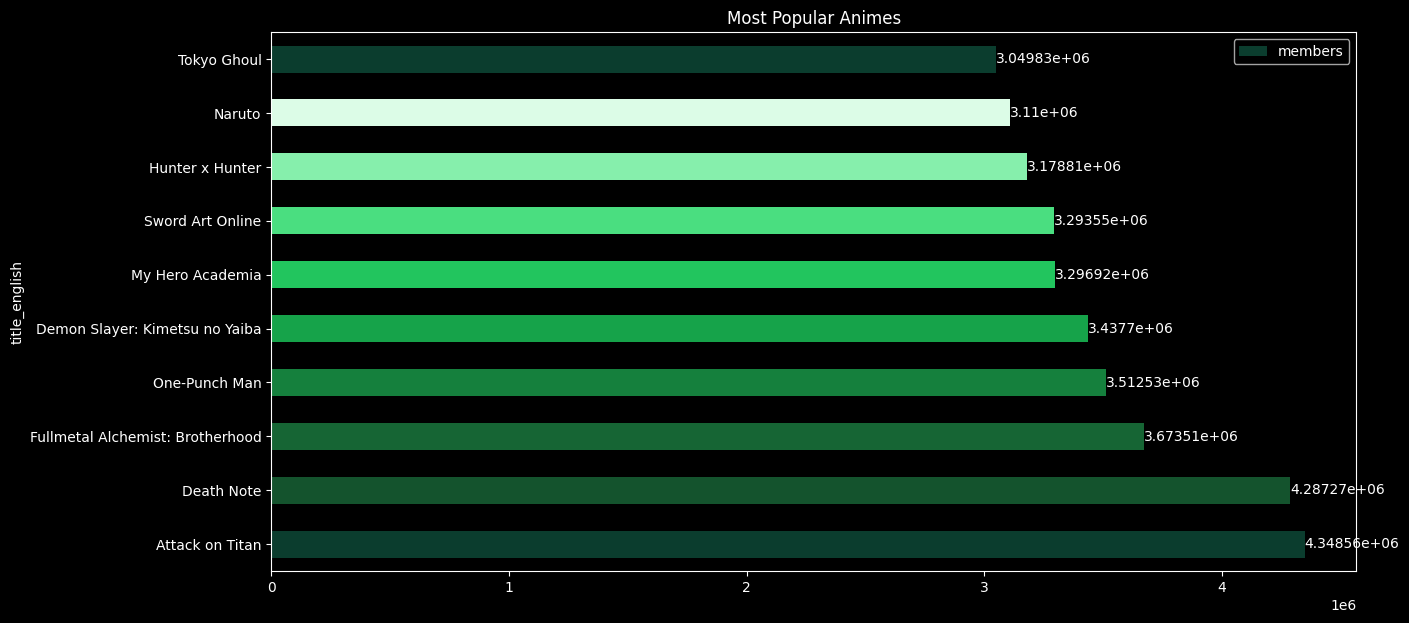

In [ ]:
top_anime =df[['title',
        'title_english',
        'members',
        'popularity',
        'genres',
        'score',
        'rank',
        'studios']].sort_values(by = 'popularity' ,ascending = True).head(10)
ax = top_anime.plot(kind = 'barh',y = 'members',x = 'title_english', figsize = (14, 7),facecolor = green_palate )
ax.bar_label(ax.containers[0])
plt.title('Most Popular Animes')
plt.show()


In [ ]:
df[['title','title_english', 'members', 'popularity', 'genres', 'score', 'rank', 'studios']].sort_values(by = 'rank' , ascending = True)

,title,title_english,members,popularity,genres,score,rank,studios
23037,Sousou no Frieren,Frieren: Beyond Journey's End,1421086,104,"[Adventure, Award Winning, Drama, Fantasy]",9.27,1.0,Madhouse
28465,Steel Ball Run: JoJo no Kimyou na Bouken,Steel Ball Run: JoJo's Bizarre Adventure,196107,1416,"[Action, Adventure, Mystery, Supernatural]",9.15,2.0,David Production
3959,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,3673510,3,"[Action, Adventure, Drama, Fantasy]",9.11,3.0,Bones
25957,Chainsaw Man Movie: Reze-hen,Chainsaw Man – The Movie: Reze Arc,457598,573,"[Action, Fantasy]",9.08,4.0,MAPPA
5662,Steins;Gate,Steins;Gate,2806159,14,"[Drama, Sci-Fi, Suspense]",9.07,5.0,White Fox
...,...,...,...,...,...,...,...,...
30069,Be My Star,Be My Star,1,29932,NaN,NaN,NaN,NaN
30070,Manzoku desu,NaN,1,29933,NaN,NaN,NaN,NaN
30071,Overlay,NaN,1,29934,NaN,NaN,NaN,NaN
30072,"Megane, Tokidoki, Yankee-kun",NaN,3,29931,"[Comedy, Romance]",NaN,NaN,NaN


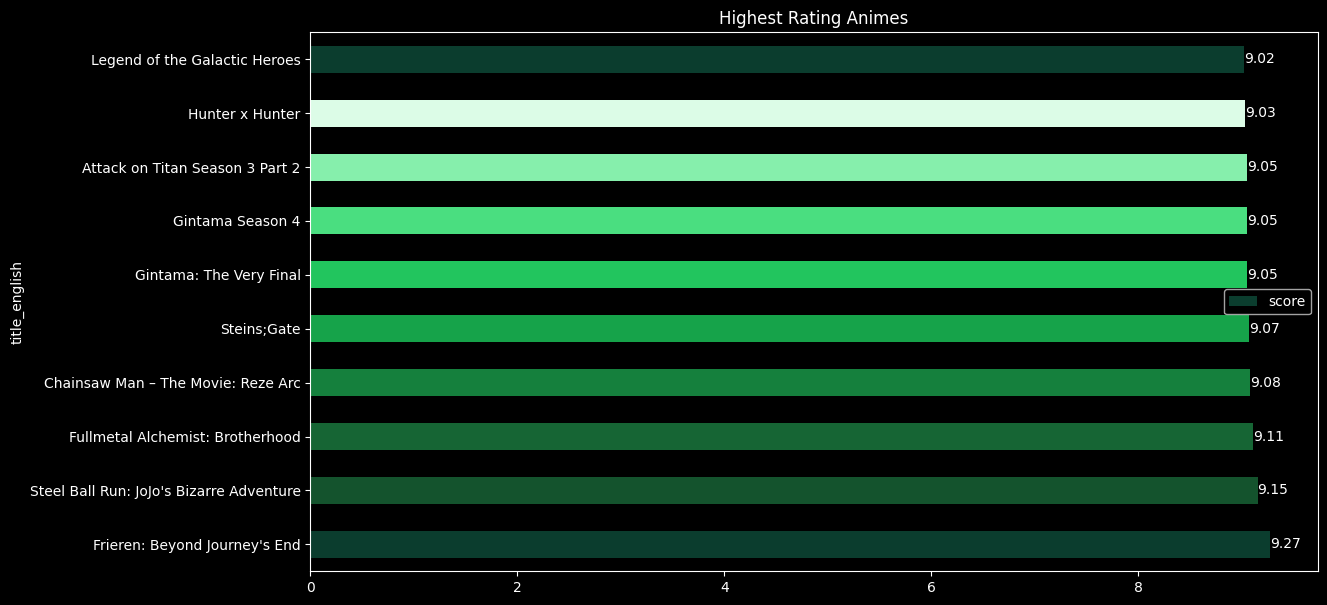

In [ ]:
top = df[['title','title_english', 'members', 'popularity', 'genres', 'score', 'rank', 'studios']].sort_values(by = 'rank' , ascending = True).head(10)
ax = top.plot(kind = 'barh',y = 'score',x = 'title_english', figsize = (13, 7),facecolor = green_palate )
ax.bar_label(ax.containers[0])
plt.title('Highest Rating Animes')
plt.show()

In [ ]:
popular_genre = popular_genre.explode('genres')
(popular_genre['genres'].value_counts() / popular_genre['genres'].value_counts().sum()) * 100

genres
Action           28.571429
Drama            14.285714
Suspense         12.500000
Fantasy          12.500000
Adventure        10.714286
Award Winning     8.928571
Supernatural      5.357143
Comedy            1.785714
Romance           1.785714
Horror            1.785714
Sci-Fi            1.785714
Name: count, dtype: float64

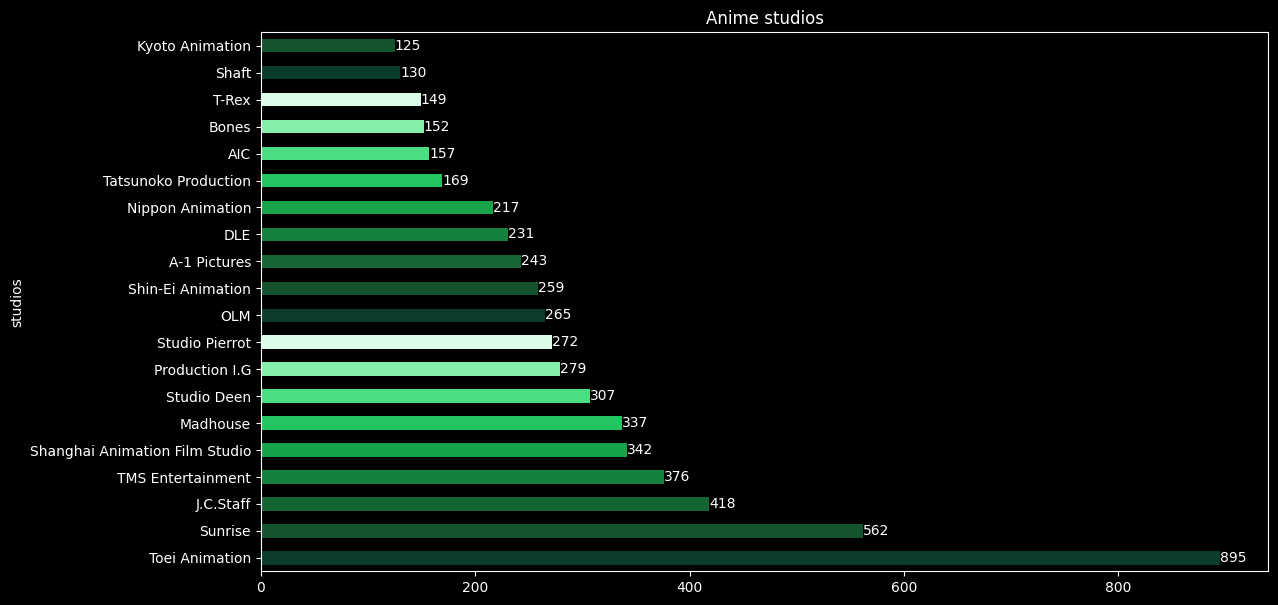

In [ ]:
ax = df['studios'].value_counts().head(20).plot(kind = 'barh', figsize = (13, 7),facecolor = green_palate )
ax.bar_label(ax.containers[0])
plt.title('Anime studios')
plt.show()

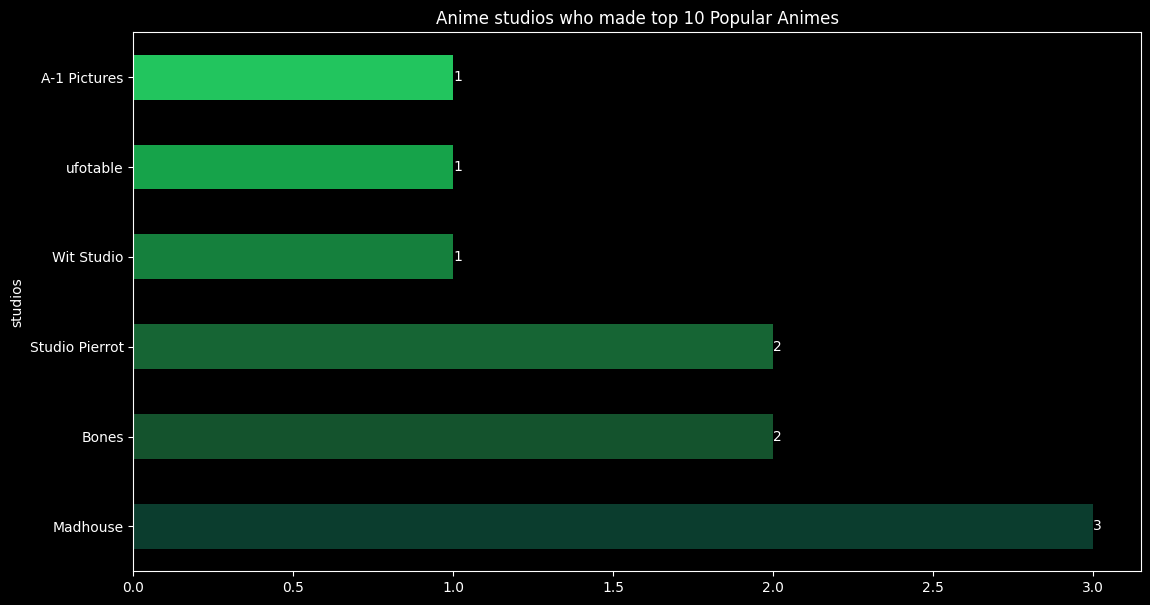

In [ ]:
ax = top_anime['studios'].value_counts().head(20).plot(kind = 'barh', figsize = (13, 7),facecolor = green_palate )
ax.bar_label(ax.containers[0])
plt.title('Anime studios who made top 10 Popular Animes')
plt.show()

In [ ]:
df[['title_english', 'studios', 'popularity']].sort_values(by = 'popularity', ascending = True).head(20).value_counts('studios')

studios
Wit Studio          4
Madhouse            3
Bones               3
Studio Pierrot      3
ufotable            1
A-1 Pictures        1
MAPPA               1
CoMix Wave Films    1
White Fox           1
Toei Animation      1
Kyoto Animation     1
Name: count, dtype: int64

In [ ]:
popular_studio = df[['title_english', 'studios', 'popularity']].sort_values(by = 'popularity', ascending = True).head(20)
popular_studio[popular_studio['studios'] == 'Madhouse']

,title_english,studios,popularity
1393,Death Note,Madhouse,2
10399,One-Punch Man,Madhouse,4
6451,Hunter x Hunter,Madhouse,8


In [ ]:
pop_st = df[['title_english', 'studios', 'popularity']].sort_values(by = 'popularity', ascending = True)
pop_st[pop_st['studios'] == 'Wit Studio'].sort_values(by = 'popularity', ascending = True).head(20)

,title_english,studios,popularity
7423,Attack on Titan,Wit Studio,1
9344,Attack on Titan Season 2,Wit Studio,13
13160,Attack on Titan Season 3,Wit Studio,18
14838,Attack on Titan Season 3 Part 2,Wit Studio,20
14206,NaN,Wit Studio,61
9461,Seraph of the End: Vampire Reign,Wit Studio,103
12715,The Ancient Magus' Bride,Wit Studio,183
9789,Kabaneri of the Iron Fortress,Wit Studio,241
9861,Seraph of the End: Battle in Nagoya,Wit Studio,255
16240,Ranking of Kings,Wit Studio,305


In [ ]:
df.columns

Index(['mal_id', 'title', 'title_english', 'type', 'source', 'episodes',
       'status', 'airing', 'aired_from', 'aired_to', 'duration', 'rating',
       'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites',
       'season', 'studios', 'genres', 'demographics'],
      dtype='str')

In [ ]:
pop = df[['title_english', 'studios', 'popularity', 'season']].sort_values(by = 'popularity', ascending = True).head(100)
pop['studios'].value_counts()

studios
Bones                               12
A-1 Pictures                         9
Madhouse                             8
Studio Pierrot                       6
Wit Studio                           5
MAPPA                                5
ufotable                             4
White Fox                            4
Kyoto Animation                      4
J.C.Staff                            4
Sunrise                              3
P.A. Works                           3
Production I.G                       3
CloverWorks                          3
Lerche                               2
Studio Deen                          2
Studio Ghibli                        2
David Production                     2
Kinema Citrus                        2
Brain's Base                         2
CoMix Wave Films                     1
Toei Animation                       1
asread.                              1
Gainax|Tatsunoko Production          1
TMS Entertainment                    1
Wit Studio|Clover

In [ ]:
pop[pop['studios'] == 'Bones']

,title_english,studios,popularity,season
3959,Fullmetal Alchemist: Brotherhood,Bones,3,spring
11125,My Hero Academia,Bones,6,spring
11847,My Hero Academia Season 2,Bones,16,spring
13546,My Hero Academia Season 3,Bones,25,spring
11199,Mob Psycho 100,Bones,27,summer
8261,Noragami,Bones,28,winter
14767,My Hero Academia Season 4,Bones,53,fall
3145,Soul Eater,Bones,65,spring
14199,Mob Psycho 100 II,Bones,73,winter
100,Fullmetal Alchemist,Bones,88,fall


In [ ]:
count_pop = pop.sort_values(by = 'popularity')['studios'].value_counts()

In [ ]:
count_df = df.sort_values(by = 'popularity')['studios'].value_counts()

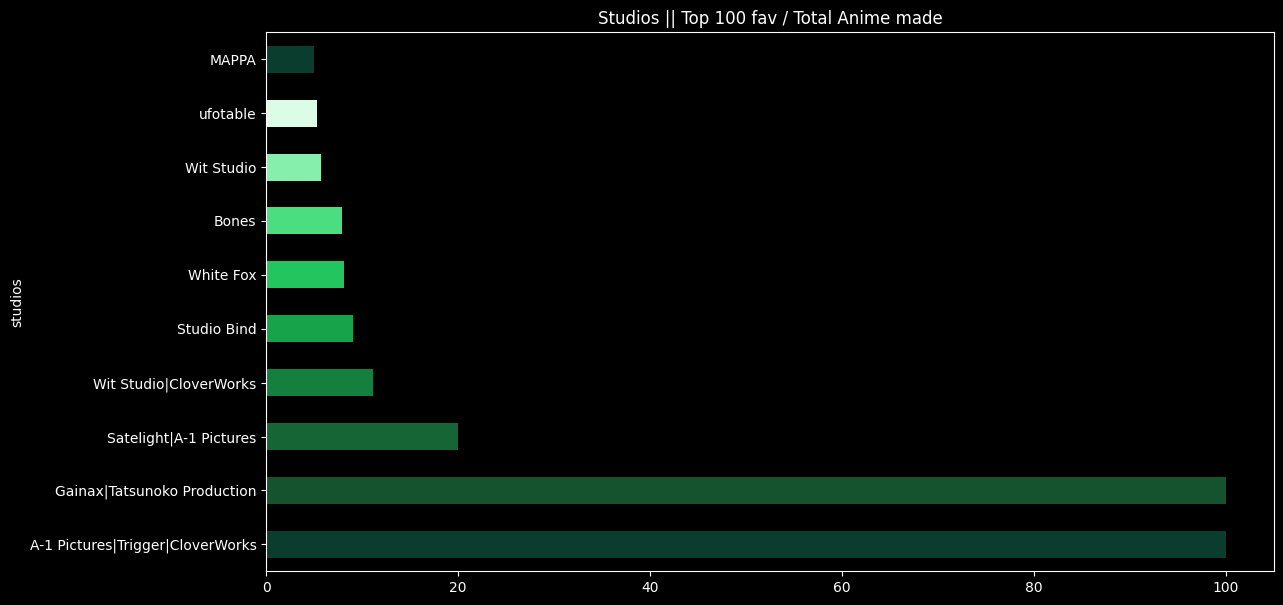

In [ ]:
percentage = (count_pop / count_df) * 100
percentage = percentage.fillna(0)
percentage[percentage != 0].sort_values(ascending = False).head(10).plot(kind = 'barh', figsize = (13, 7),facecolor = green_palate )
plt.title('Studios || Top 100 fav / Total Anime made')
plt.show()

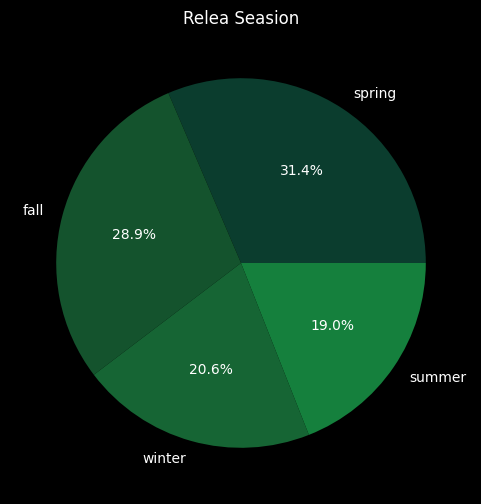

In [ ]:
plt.style.use('dark_background')
df["season"].value_counts(dropna = True).plot(
    kind='pie',
    figsize=(6,6),
    autopct = '%1.1f%%',
    colors = green_palate
)
plt.title("Relea Seasion")
plt.show()

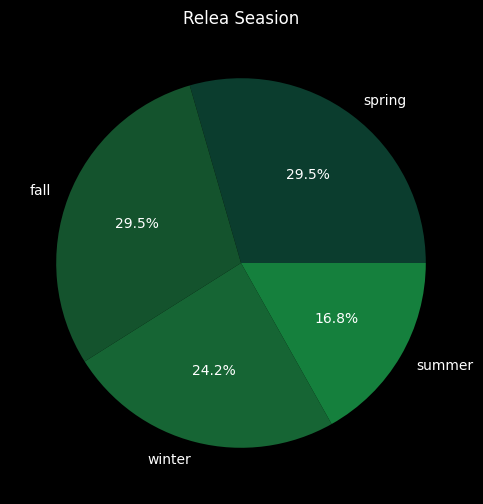

In [ ]:
plt.style.use('dark_background')
pop["season"].value_counts(dropna = True).plot(
    kind='pie',
    figsize=(6,6),
    autopct = '%1.1f%%',
    colors = green_palate
)
plt.title("Relea Seasion")
plt.show()

# Key Findings
- Anime around 30% are TV shows, followed by movies and Music with 17% and 15% respectively.
- About 43% of the Anime are originals, while 18% of the stories are adapted from manga.
- About 34% Anime with original storylines are TV shows.
- In this list, there are 12 total anime with more than 1000 episodes.
- One Piece episode count not available. Probably because Anime is on air.   
- Anime with the most episodes is 'Lan Mao' or 'Why's of Blue Cat	' with 3000 episodes.
- Our initial suspicion turned out to be wrong. There is no similarity in the trend shown between column score and popularity. Even the column episode has almost no correlation with anything.
-  More then 18% of the anime are of 'Comedy' genres, followed by 'Fantasy' and 'Action' genres with 14% and 11% respectively
-  Top 10 Anime based on Members and Popularity.
     1. Attack on Titan
     2. Death Note
     3. Fullmetal Alchemist: Brotherhood
     4. One-Punch Man
     5. Demon Slayer: Kimetsu no Yaiba
     6. My Hero Academia
     7. Sword Art Online
     8. Hunter x Hunter
     9. Naruto
    10. Tokyo Ghoul
- Top 10 Anime based on official Score and ratings
    1. Frieren: Beyond Journey's End
    2. Steel Ball Run: JoJo's Bizarre Adventure
    3. Fullmetal Alchemist: Brotherhood
    4. Chainsaw Man – The Movie: Reze Arc
    5. Steins; Gate
    6. Gintama: The Very Final
    7. Gintama Season 4
    8. Attack on Titan Season 3 Part 2
    9. Hunter x Hunter
   10. Legend of the Galactic Heroes
- Between top 20 popular Animes, close to 30% are of Action genre.  
- Studio 'Toei Animation' made 895 Animes which is higest till now.
- Between top 20 popular Animes 'Wit Studio' made 4 of them, but they are just different parts of a single anime storyline 'Attack on Titne'.
- Most animes are release in spring. ( *reason try to find letter* )

# Questions
- What is the type distribution and max which type avalable here. *
- what is the sourse. *
- Anime with most episodes. *
- Is number of episodes affect the score and popularity. *
- What are the most popular genera. *
- What is the most number genera in the marcket. *
- Best studio out of all.  **can't find any direct answer to this question*